# `GEA` demo: T2D cohort in mouse data from CELLxGENE

## Getting data from CELLxGENE

In [1]:
import cellxgene_census
import scanpy as sc
from scipy.sparse import csr_matrix
import re

In [2]:
with cellxgene_census.open_soma() as census:

    adata = cellxgene_census.get_anndata(
        census=census,
        organism="Mus musculus",
        obs_value_filter=(
            "tissue_type == 'tissue' "
            "and tissue == 'islet of Langerhans' "  # specific tissue type located on pancreas
            "and is_primary_data == True"
        ),
    )

The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.
/home/s243564/miniforge3/envs/gea/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/s243564/miniforge3/envs/gea/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [3]:
def process_tabula_dataset(adata, species_name, cell_type_number_filter=350):
    print(f"\n--- Processing {species_name} ---")

    print(f"Initial cells: {adata.n_obs}, Initial genes: {adata.n_vars}")

    # 1. Map 10x 3' Assay safely
    adata = adata[
        adata.obs["assay"].isin({"10x 3' v2", "10x 3' v3"})
    ].copy()
    print(f"Cells remaining after 10x 3' assay filter: {adata.n_obs}")

    # 2. Filter by Cell Type Count (> 350 cells per cell type)
    if cell_type_number_filter > 0:
        vc = adata.obs["cell_type"].value_counts()
        valid_cell_types = vc[vc > cell_type_number_filter].index
        adata = adata[adata.obs["cell_type"].isin(valid_cell_types)].copy()
        print(f"Cells remaining after cell type count filter: {adata.n_obs}")

    # 3. Retain protein-coding genes only
    protein_coding_mask = (
        adata.var["feature_type"] == "protein_coding"
    )  # feature_type in sapiens and muris, check for others
    adata = adata[:, protein_coding_mask].copy()
    print(f"Genes remaining after protein-coding filter: {adata.n_vars}")

    # 4. Filter cells with less than 500 genes expressed
    sc.pp.filter_cells(adata, min_genes=500)
    print(f"Cells remaining after gene count filter: {adata.n_obs}")

    # 5. Filter genes expressed in less than 1000 cells
    sc.pp.filter_genes(adata, min_cells=1000)
    print(f"Genes remaining after cell count filter: {adata.n_vars}")

    print("\n--- Final Dataset Summary ---\n")

    print(f"Final cells: {adata.n_obs}, Final genes: {adata.n_vars}")

    return adata

In [4]:
adata_filter = process_tabula_dataset(adata, species_name="Mouse pancreatic data")


--- Processing Mouse pancreatic data ---
Initial cells: 264235, Initial genes: 53384
Cells remaining after 10x 3' assay filter: 264235
Cells remaining after cell type count filter: 263991
Genes remaining after protein-coding filter: 21677
Cells remaining after gene count filter: 261636
Genes remaining after cell count filter: 14330

--- Final Dataset Summary ---

Final cells: 261636, Final genes: 14330


In [5]:
keep_tissue = ["type B pancreatic cell", "pancreatic A cell", "pancreatic D cell", "pancreatic stellate cell", "endothelial cell", "pancreatic ductal cell", "pancreatic PP cell"]
keep_phenotype = ["normal", "type 2 diabetes mellitus"]

adata_filter_cells = adata_filter[adata_filter.obs["cell_type"].isin(keep_tissue) & adata_filter.obs["disease"].isin(keep_phenotype)].copy()

adata_filter_cells.obs.groupby(["cell_type", "disease"]).size()

/tmp/ipykernel_4006359/710005710.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_filter_cells.obs.groupby(["cell_type", "disease"]).size()


cell_type                 disease                 
endothelial cell          normal                       4383
                          type 2 diabetes mellitus     3886
pancreatic A cell         normal                      16200
                          type 2 diabetes mellitus    15711
pancreatic D cell         normal                       7354
                          type 2 diabetes mellitus    10896
pancreatic PP cell        normal                       2257
                          type 2 diabetes mellitus     3291
pancreatic ductal cell    normal                       2007
                          type 2 diabetes mellitus     3100
pancreatic stellate cell  normal                       5103
                          type 2 diabetes mellitus     4809
type B pancreatic cell    normal                      54253
                          type 2 diabetes mellitus    32779
dtype: int64

## Pseudobulk aggregation — `donor_id` × `cell_type` × `disease`

The GEA pipeline (LIONESS + PPI prior) treats **one sample = one graph**, and LIONESS is a
**bulk** method: it infers a sample-specific network as a leave-one-out perturbation of a
Pearson gene–gene co-expression matrix. Applying it per *cell* is both statistically wrong
(scRNA-seq is sparse/zero-inflated, and a single cell barely perturbs a correlation over
10⁵ cells) and computationally infeasible (~166 k graphs, hundreds of GB).

The right unit of analysis is the **pseudobulk profile**: sum raw counts across all cells of a
given `(donor, cell_type, disease)` group. This yields ~200 robust, bulk-like profiles —
the same regime as the 303-sample IBD cohort — and preserves **both axes of variation**:
disease becomes the graph label, cell type a covariate (or the LIONESS grouping variable).
Note that in this cohort **disease is a donor-level property** (a donor is either normal or
T2D), so `× disease` mainly serves as a label; the profile count is driven by donors × cell types.

In [6]:
import numpy as np, pandas as pd
from scipy.sparse import csr_matrix

GROUP_KEYS = ["donor_id", "cell_type", "disease"]
MIN_CELLS  = 20        # pseudobulks below this are statistically unreliable → dropped

obs = adata_filter_cells.obs.copy()
for k in GROUP_KEYS:
    obs[k] = obs[k].astype(str)

# One pseudobulk = SUM of raw counts over every cell in a (donor, cell_type, disease) group.
# Implemented as a sparse group-indicator matmul: indicatorᵀ · X  →  [groups × genes].
labels = obs[GROUP_KEYS].agg(" | ".join, axis=1)
codes, uniques = pd.factorize(labels)
ind = csr_matrix((np.ones(adata_filter_cells.n_obs),
                  (np.arange(adata_filter_cells.n_obs), codes)),
                 shape=(adata_filter_cells.n_obs, len(uniques)))
pb      = np.asarray((ind.T @ adata_filter_cells.X).todense())   # [groups × genes] summed counts
n_cells = np.asarray(ind.sum(axis=0)).ravel().astype(int)

# Mouse Ensembl IDs (ENSMUSG…) as the gene index — required by the downstream STRING /
# embedding steps (remember to query STRING with species=10090, mygene species='mouse').
var      = adata_filter_cells.var
gene_ids = (var["feature_id"] if "feature_id" in var.columns else var.index).astype(str).values

pb_meta = pd.DataFrame([u.split(" | ") for u in uniques], columns=GROUP_KEYS)
pb_meta["n_cells"]   = n_cells
pb_meta["sample_id"] = (pb_meta["donor_id"] + "|"
                        + pb_meta["cell_type"].str.replace(" ", "_") + "|"
                        + pb_meta["disease"].str.replace(" ", "_"))

keep = pb_meta["n_cells"].values >= MIN_CELLS
pb_counts = pd.DataFrame(pb[keep].T, index=gene_ids,
                         columns=pb_meta.loc[keep, "sample_id"].values)
pb_counts.index.name = "Geneid"
pb_meta = pb_meta.loc[keep].reset_index(drop=True)

# Persist in the same layout as the IBD tutorial (genes × samples counts + metadata table),
# so the existing gea loaders / LIONESS pipeline can consume it unchanged.
pb_counts.to_csv("data/t2d/tutorial-t2d-pseudobulk-matrix.tsv", sep="\t")
pb_meta.to_csv("data/t2d/tutorial-t2d-pseudobulk-metadata.csv", index=False)

print(f"Pseudobulk matrix : {pb_counts.shape[0]} genes × {pb_counts.shape[1]} samples")
print(f"Donors            : {pb_meta['donor_id'].nunique()}  "
      f"(dropped {int((~keep).sum())} groups with <{MIN_CELLS} cells)")
pb_meta.head()

Pseudobulk matrix : 14330 genes × 196 samples
Donors            : 34  (dropped 33 groups with <20 cells)


,donor_id,cell_type,disease,n_cells,sample_id
0,mouse_pancreatic_islet_atlas_Hrovatin__NOD_eli...,pancreatic stellate cell,normal,1425,mouse_pancreatic_islet_atlas_Hrovatin__NOD_eli...
1,mouse_pancreatic_islet_atlas_Hrovatin__STZ__G2,pancreatic PP cell,type 2 diabetes mellitus,312,mouse_pancreatic_islet_atlas_Hrovatin__STZ__G2...
2,mouse_pancreatic_islet_atlas_Hrovatin__VSG__MU...,pancreatic D cell,type 2 diabetes mellitus,199,mouse_pancreatic_islet_atlas_Hrovatin__VSG__MU...
3,mouse_pancreatic_islet_atlas_Hrovatin__STZ__G5,pancreatic PP cell,type 2 diabetes mellitus,767,mouse_pancreatic_islet_atlas_Hrovatin__STZ__G5...
4,mouse_pancreatic_islet_atlas_Hrovatin__VSG__MU...,type B pancreatic cell,type 2 diabetes mellitus,2205,mouse_pancreatic_islet_atlas_Hrovatin__VSG__MU...


### Composition — how many profiles per cell type × disease?

Pseudobulk profiles per cell type × disease:

disease                   normal  type 2 diabetes mellitus
cell_type                                                 
endothelial cell              13                        12
pancreatic A cell             22                        12
pancreatic D cell             22                        12
pancreatic PP cell            17                        12
pancreatic ductal cell         8                        10
pancreatic stellate cell      10                        12
type B pancreatic cell        22                        12

Total profiles: 196 | donors: 34 (normal 22, T2D 12)


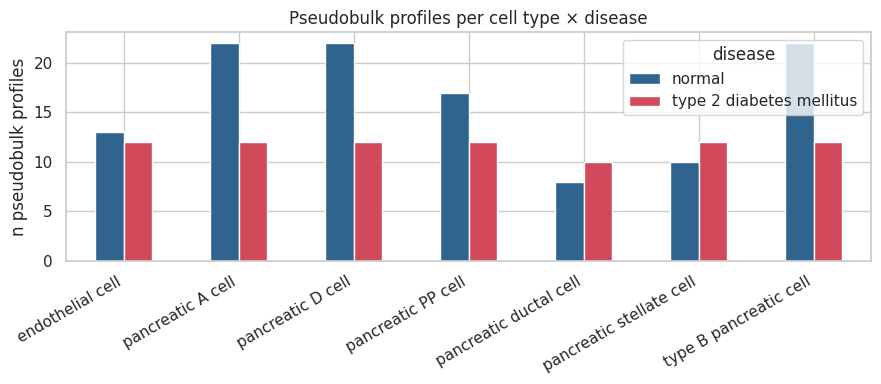

In [7]:
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
DPAL = {"normal": "#30638e", "type 2 diabetes mellitus": "#d1495b"}

comp = pd.crosstab(pb_meta["cell_type"], pb_meta["disease"])
print("Pseudobulk profiles per cell type × disease:\n")
print(comp.to_string())
n_norm = pb_meta[pb_meta.disease == "normal"]["donor_id"].nunique()
n_t2d  = pb_meta[pb_meta.disease != "normal"]["donor_id"].nunique()
print(f"\nTotal profiles: {len(pb_meta)} | donors: {pb_meta['donor_id'].nunique()} "
      f"(normal {n_norm}, T2D {n_t2d})")

ax = comp.plot(kind="bar", figsize=(9, 4),
               color=[DPAL.get(c, "#888") for c in comp.columns])
ax.set_ylabel("n pseudobulk profiles"); ax.set_xlabel("")
ax.set_title("Pseudobulk profiles per cell type × disease")
plt.xticks(rotation=30, ha="right"); plt.legend(title="disease")
plt.tight_layout(); plt.show()

### Per-profile QC — cells aggregated, library size, gene detection

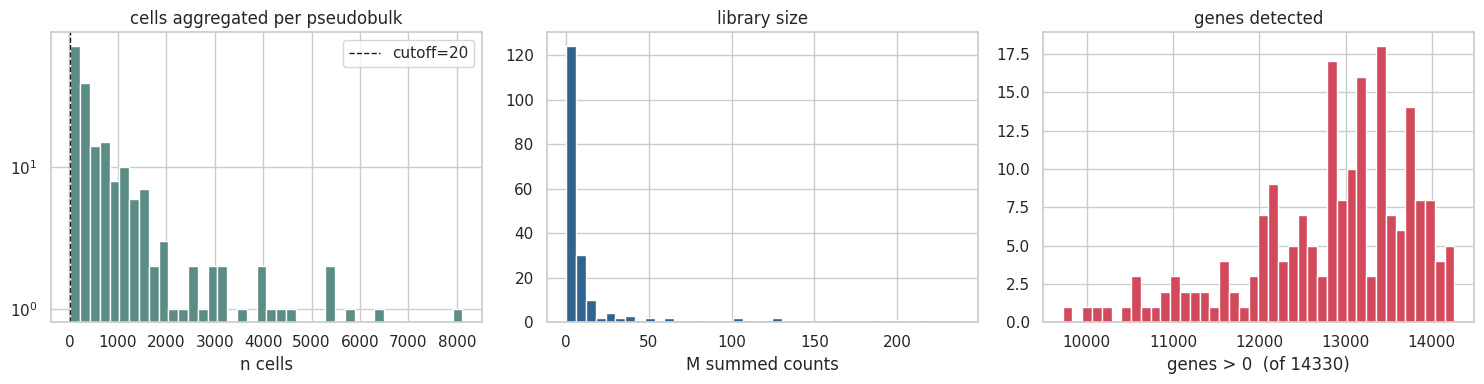

cells per pseudobulk:
 count     196.0
mean      846.0
std      1271.0
min        23.0
25%       136.0
50%       319.0
75%       972.0
max      8114.0


In [8]:
lib       = pb_counts.sum(axis=0)
genes_det = (pb_counts > 0).sum(axis=0)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(pb_meta["n_cells"], bins=40, color="#5b8c85"); ax[0].set_yscale("log")
ax[0].axvline(MIN_CELLS, color="k", ls="--", lw=1, label=f"cutoff={MIN_CELLS}")
ax[0].set_title("cells aggregated per pseudobulk"); ax[0].set_xlabel("n cells"); ax[0].legend()
ax[1].hist(lib/1e6, bins=40, color="#30638e")
ax[1].set_title("library size"); ax[1].set_xlabel("M summed counts")
ax[2].hist(genes_det, bins=40, color="#d1495b")
ax[2].set_title("genes detected"); ax[2].set_xlabel(f"genes > 0  (of {pb_counts.shape[0]})")
plt.tight_layout(); plt.show()

print("cells per pseudobulk:\n", pb_meta["n_cells"].describe().round(0).to_string())

### The two axes of variation: cell type vs disease

Your stated concern is that this dataset carries **two** structured sources of variation.
A PCA of the pseudobulk profiles makes them visible, and a simple variance partition
quantifies how much of the expression variance each factor explains.

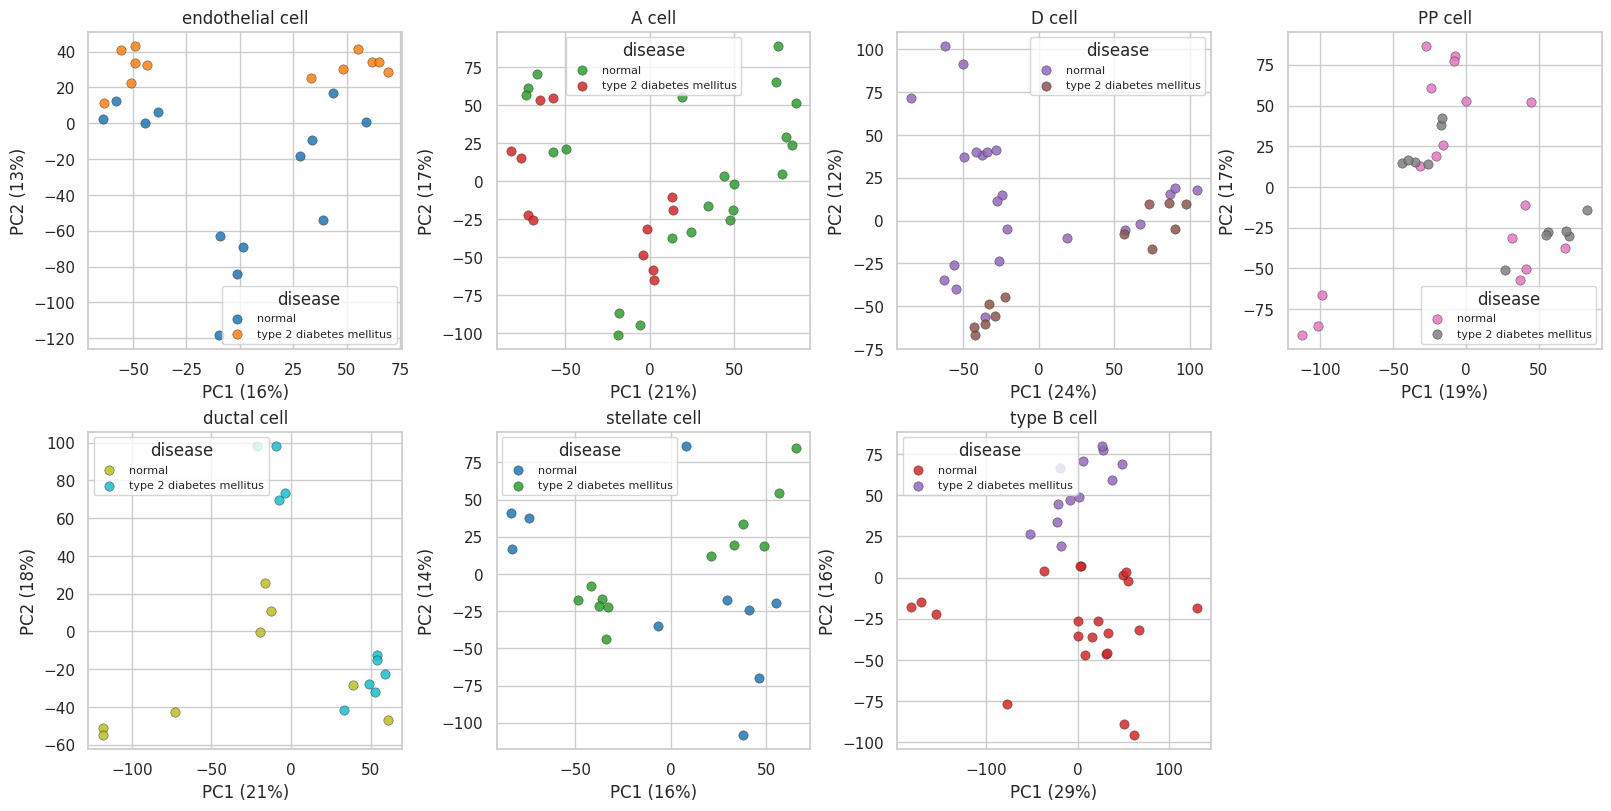

In [9]:
from gea.preprocessing import normalize_counts
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

norm = normalize_counts(pb_counts)                     # samples × genes, log2(CPM+1)
m    = pb_meta.set_index("sample_id").loc[norm.index]  # align metadata to matrix rows

ct_names = sorted(m["cell_type"].unique())
diseases = sorted(m["disease"].unique())

# Create distinct color palettes for each subplot
color_schemes = [
    {"normal": "#1f77b4", "type 2 diabetes mellitus": "#ff7f0e"},  # blue, orange
    {"normal": "#2ca02c", "type 2 diabetes mellitus": "#d62728"},  # green, red
    {"normal": "#9467bd", "type 2 diabetes mellitus": "#8c564b"},  # purple, brown
    {"normal": "#e377c2", "type 2 diabetes mellitus": "#7f7f7f"},  # pink, gray
    {"normal": "#bcbd22", "type 2 diabetes mellitus": "#17becf"},  # yellow-green, cyan
    {"normal": "#1f77b4", "type 2 diabetes mellitus": "#2ca02c"},  # blue, green
    {"normal": "#d62728", "type 2 diabetes mellitus": "#9467bd"},  # red, purple
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
axes = axes.ravel()

for i, ct in enumerate(ct_names):
    ax = axes[i]
    sel = m["cell_type"] == ct
    X_ct = norm.loc[sel].values
    Xs_ct = StandardScaler().fit_transform(X_ct)
    pca_ct = PCA(n_components=2, random_state=42).fit(Xs_ct)
    XP_ct = pca_ct.transform(Xs_ct)

    ct_meta = m.loc[sel]
    palette = color_schemes[i]

    for d in diseases:
        sel_d = ct_meta["disease"] == d
        ax.scatter(
            XP_ct[sel_d, 0],
            XP_ct[sel_d, 1],
            s=45,
            alpha=0.85,
            color=palette[d],
            edgecolor="k",
            linewidth=0.3,
            label=d,
        )

    ax.set_title(ct.replace("pancreatic ", ""))
    ax.set_xlabel(f"PC1 ({pca_ct.explained_variance_ratio_[0]:.0%})")
    ax.set_ylabel(f"PC2 ({pca_ct.explained_variance_ratio_[1]:.0%})")
    ax.legend(fontsize=8, title="disease")

for j in range(len(ct_names), len(axes)):
    axes[j].set_visible(False)

plt.show()

## LIONESS + PPI network construction

We now apply the GEA framework — z-space LIONESS with a STRING PPI prior — to the pseudobulk
profiles, mirroring the IBD tutorial with three deliberate choices:

- **Grouping variable = `cell_type`.** LIONESS builds its background co-expression network per
  group. Grouping by cell type (not by the label) keeps the aggregate network blind to disease,
  which avoids the per-group label-leakage failure mode. Each sample's network is then its
  leave-one-out deviation from its own cell type's background.
- **Two graph-level labels:** `disease` (primary phenotype objective) and `cell_type` (second
  objective). Both are attached to every graph.
- **Mouse adaptations:** STRING `species=10090`, `mygene species='mouse'`, and we do **not** call
  `filter_protein_coding` (hard-coded to human `ENSG…`; QC was already done upstream).

In [10]:
# ── Resume point ────────────────────────────────────────────────────────────
# Lets you run the modelling section without re-fetching CELLxGENE: if the
# pseudobulk objects aren't in memory, reload them from the saved artefacts.
import pandas as pd
try:
    pb_counts, pb_meta
except NameError:
    pb_counts = pd.read_csv("data/t2d/tutorial-t2d-pseudobulk-matrix.tsv", sep="\t", index_col="Geneid")
    pb_meta   = pd.read_csv("data/t2d/tutorial-t2d-pseudobulk-metadata.csv")
    print("(resumed) reloaded pseudobulk from disk")
print(f"Pseudobulk: {pb_counts.shape[0]} genes × {pb_counts.shape[1]} samples")

Pseudobulk: 14330 genes × 196 samples


### Gene filtering + STRING PPI prior (mouse)

In [11]:
from gea.preprocessing import filter_genes

# Same abundance + variance filter as the IBD tutorial: keep highly expressed,
# high-variance genes so the co-expression matrices are tractable and informative.
filt_counts = filter_genes(pb_counts, cpm_threshold=1, min_frac=0.1, pct=0.1)
print(f"CPM + variance filter: {pb_counts.shape[0]} → {filt_counts.shape[0]} genes")

CPM + variance filter: 14330 → 1382 genes


In [12]:
import mygene

# Ensembl (ENSMUSG) → gene symbol, needed to query STRING. species='mouse' (not human!).
mg = mygene.MyGeneInfo()
info = mg.querymany(filt_counts.index.tolist(), scopes="ensembl.gene",
                    fields="symbol", species="mouse", as_dataframe=True, verbose=False)
info = info[~info.index.duplicated(keep="first")]
ensembl_to_symbol = info["symbol"].dropna().to_dict()
print(f"Mapped {len(ensembl_to_symbol)}/{filt_counts.shape[0]} genes to mouse symbols")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Mapped 1382/1382 genes to mouse symbols


In [13]:
from gea.dataloader import load_string_ppi_network
from gea.utils import get_gene_list

# species=10090 = Mus musculus. ensembl_to_symbol lets STRING be queried with symbols
# and enriches the returned network with ensemblId_A / ensemblId_B columns.
gene_list = get_gene_list(filt_counts)          # ENSMUSG IDs
ppi_network = load_string_ppi_network(
    gene_list, species=10090, conf_score=600, ensembl_to_symbol=ensembl_to_symbol,
)
print(ppi_network[["preferredName_A", "preferredName_B", "score"]].head())

Successfully retrieved PPI network!
Found 5697 interactions.
  preferredName_A preferredName_B  score
0            Cav2            Ehd2  0.614
1            Cav2           Itgb6  0.650
2            Cav2          Cavin3  0.685
3            Cav2          Cavin2  0.688
4            Cav2           Itgb4  0.696


In [14]:
from gea.preprocessing import filter_ppi_nodes

# Keep only genes that appear in the PPI network — these become the graph nodes.
filt_counts_ppi = filter_ppi_nodes(filt_counts, ppi_network)
print(f"Genes retained in PPI network: {filt_counts.shape[0]} → {filt_counts_ppi.shape[0]}")

Genes retained in PPI network: 1382 → 1030


### Node embeddings — mouse ESM-2 (identical procedure to the IBD tutorial)

Node features are `[expression | ESM-2 protein embedding]`. The gene list was exported to
`data/t2d/ensembl_ids_t2d.txt` and embeddings were computed **exactly as in the IBD tutorial** with
`scripts/get_esm_embeddings.py` — same ESM-2 model (`facebook/esm2_t33_650M_UR50D`), CLS-token
representation, isoforms aggregated by mean — only pointed at the **mouse** proteome
(`Mus_musculus.GRCm39.pep.all`, `--fasta data/t2d/mouse_pep.fa.gz`). We then compress 1280→256 dims
with whitened PCA, as in IBD.

In [15]:
from gea.utils import load_esm_embeddings, compress_embeddings_pca, get_gene_list

# Node order must match the graph gene order = columns of the normalised matrix = filt_counts_ppi.index
gene_list_ppi = get_gene_list(filt_counts_ppi)

# Load pre-computed mouse ESM-2 embeddings (mean over isoforms), then PCA-compress + L2-renorm.
esm_embeddings = load_esm_embeddings(
    esm_file="data/t2d/esm_embeddings_t2d.pt", ensembl_ids=gene_list_ppi, aggregation="mean",
)
esm_embeddings = compress_embeddings_pca(esm_embeddings, n_components=256, whiten=True)
print(f"ESM-2 embedding matrix after PCA: {tuple(esm_embeddings.shape)}  (genes × 256)")

Loading ESM-2 embeddings: 100%|██████████| 1030/1030 [00:00<00:00, 37185.79it/s]

Found ESM-2 embeddings for 1030/1030 genes.


PCA: 1280→256 dims, 95.1% variance retained.
ESM-2 embedding matrix after PCA: (1030, 256)  (genes × 256)


### Normalize counts and assemble the joint matrix

In [16]:
from gea.preprocessing import normalize_counts

# log2(CPM+1); returns samples × genes. Then attach the grouping var (cell_type)
# and both labels (disease, cell_type) — merge_metadata is bypassed because we
# already hold the metadata.
norm_counts = normalize_counts(filt_counts_ppi)
joint_data  = norm_counts.join(
    pb_meta.set_index("sample_id")[["cell_type", "disease"]]
)
print(f"joint_data: {joint_data.shape}  (samples × [genes + cell_type + disease])")
print(joint_data["disease"].value_counts().to_string())

joint_data: (196, 1032)  (samples × [genes + cell_type + disease])
disease
normal                      114
type 2 diabetes mellitus     82


### Gene co-expression per cell type + z-space LIONESS with the PPI prior

In [17]:
from gea.preprocessing import get_corr_matrix, lioness_ppi

# One aggregate co-expression matrix per cell type (the LIONESS background).
gene_corrs, grouped_data = get_corr_matrix(joint_data, group_by="cell_type")
print(f"{len(grouped_data)} cell-type groups; sample counts per group:",
      [gd.shape[0] for gd in grouped_data])

# For each cell type, LIONESS derives a sample-specific network per profile, keeping only
# PPI edges whose |correlation| exceeds the threshold.
sample_networks = lioness_ppi(grouped_data, gene_corrs, ppi_network, threshold=0.25)
print(f"Built {len(sample_networks)} sample-specific networks")

7 cell-type groups; sample counts per group: [22, 29, 34, 34, 34, 25, 18]


LIONESS samples (PPI filtered) for group 7/7: 100%|██████████| 18/18 [00:00<00:00, 20.56it/s]

Built 196 sample-specific networks


### Convert to PyG graphs with two labels

`bio_col='disease'` sets the primary graph label `y`; `bio_col2='cell_type'` attaches the second
label `y_ct` used by the cell-type objective. `standardize_expr` z-scores each gene's expression
across samples (same as IBD).

In [18]:
from gea.preprocessing import gene_networks_to_pyg
import torch

t2d_graphs = gene_networks_to_pyg(
    sample_networks, joint_data, esm_embeddings,
    bio_col="disease", bio_col2="cell_type", standardize_expr=True,
)
torch.save(t2d_graphs, "data/t2d/t2d_graphs.pt")
print(f"Built and saved {len(t2d_graphs)} PyG graphs → data/t2d/t2d_graphs.pt")
print(f"Node feature dim: {t2d_graphs[0].x.shape[1]}  (1 expr + 256 ESM-2 PCA)")
print("Has y (disease):", hasattr(t2d_graphs[0], "y"), "| has y_ct (cell type):", hasattr(t2d_graphs[0], "y_ct"))

Building PyG Data objects for sample-specific networks: 100%|██████████| 196/196 [00:26<00:00,  7.38it/s]


Built and saved 196 PyG graphs → data/t2d/t2d_graphs.pt
Node feature dim: 257  (1 expr + 256 ESM-2 PCA)
Has y (disease): True | has y_ct (cell type): True


### Graph statistics

Graphs        : 196
Nodes / graph : 1030  |  feature dim: 257
Directed edges/graph: min 7038, mean 8773, max 10562  | pos-edge 69.2%
Disease labels : {'normal': 114, 'type 2 diabetes mellitus': 82}
Cell-type labels: {'endothelial cell': 25, 'pancreatic A cell': 34, 'pancreatic D cell': 34, 'pancreatic PP cell': 29, 'pancreatic ductal cell': 18, 'pancreatic stellate cell': 22, 'type B pancreatic cell': 34}


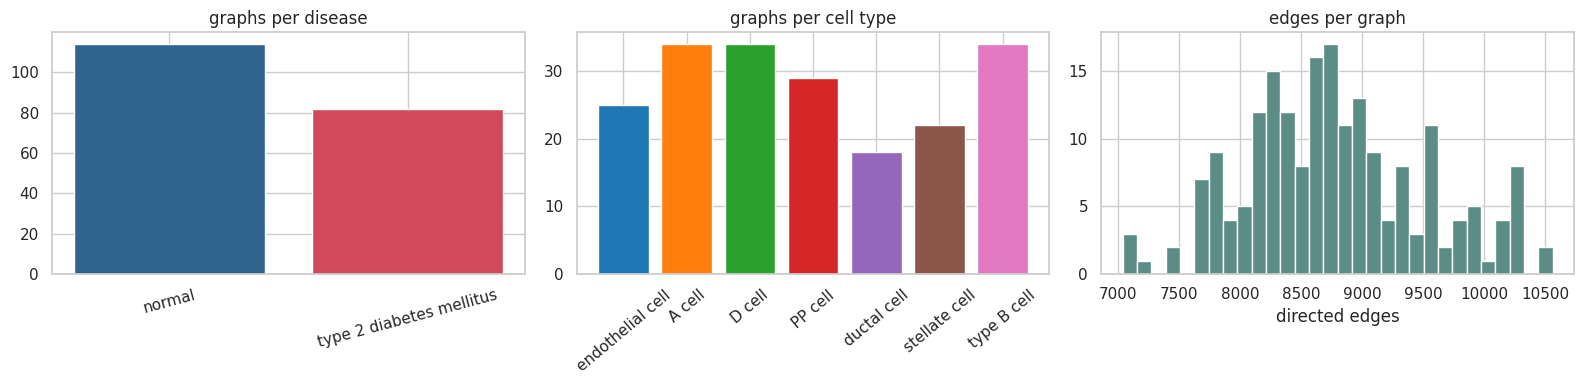

In [19]:
import numpy as np, collections, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

disease_names = sorted(joint_data["disease"].unique())     # label int → name
ct_names      = sorted(joint_data["cell_type"].unique())
y    = np.array([g.y.item() for g in t2d_graphs])
y_ct = np.array([g.y_ct.item() for g in t2d_graphs])
ne   = np.array([g.edge_index.shape[1] for g in t2d_graphs])
pos_frac = np.array([(g.edge_type == 0).float().mean().item() for g in t2d_graphs])

print(f"Graphs        : {len(t2d_graphs)}")
print(f"Nodes / graph : {t2d_graphs[0].x.shape[0]}  |  feature dim: {t2d_graphs[0].x.shape[1]}")
print(f"Directed edges/graph: min {ne.min()}, mean {ne.mean():.0f}, max {ne.max()}  | pos-edge {pos_frac.mean():.1%}")
print("Disease labels :", {disease_names[k]: int(v) for k, v in sorted(collections.Counter(y).items())})
print("Cell-type labels:", {ct_names[k]: int(v) for k, v in sorted(collections.Counter(y_ct).items())})

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar([disease_names[k] for k in sorted(set(y))],
          [ (y==k).sum() for k in sorted(set(y)) ], color=["#30638e", "#d1495b"])
ax[0].set_title("graphs per disease"); ax[0].tick_params(axis="x", rotation=15)
ax[1].bar([ct_names[k].replace("pancreatic ", "") for k in sorted(set(y_ct))],
          [ (y_ct==k).sum() for k in sorted(set(y_ct)) ], color=sns.color_palette("tab10", len(ct_names)))
ax[1].set_title("graphs per cell type"); ax[1].tick_params(axis="x", rotation=40)
ax[2].hist(ne, bins=30, color="#5b8c85"); ax[2].set_title("edges per graph"); ax[2].set_xlabel("directed edges")
plt.tight_layout(); plt.show()

## Training the multi-task GNN

Trained **exactly as in `tutorial-ibd.ipynb`** (same `GNNModel`, same `train_gnn`, stratified
80/20 split, `input_proj_dim=None`, 200 epochs), with one addition: a **second graph-level
objective**. The model now optimises three losses jointly:

1. **Disease** classification (`normal` vs `T2D`) — primary phenotype head,
2. **Cell type** classification (7 classes) — second head (`n_classes_ct=7`),
3. **Edge-weight** prediction — the self-supervised co-expression objective.

> The split is stratified by disease to match the IBD procedure. ⚠ For a rigorous evaluation use
> a **donor-grouped** split (profiles from one donor across cell types must not straddle
> train/test); here we keep IBD's procedure for a like-for-like comparison.

In [20]:
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

# Stratified 80/20 split by disease (same as IBD, which stratified by its phenotype label).
train_graphs, test_graphs = train_test_split(
    t2d_graphs, test_size=0.2, random_state=42, stratify=[g.y.item() for g in t2d_graphs],
)
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_graphs,  batch_size=32, shuffle=False)
embed_loader = DataLoader(t2d_graphs,   batch_size=32, shuffle=False)   # all graphs, for SAE/GEA later
print(f"Train: {len(train_graphs)} | Test: {len(test_graphs)} graphs")

Train: 156 | Test: 40 graphs


In [21]:
from gea.gea import set_seed, GNNModel
import torch

set_seed(42)  # reproducible weight init
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

in_dim       = t2d_graphs[0].x.shape[1]                       # 1 expr + 256 ESM-2 PCA
n_classes    = len(sorted({g.y.item() for g in t2d_graphs}))  # 2: normal, T2D
n_classes_ct = len(sorted({g.y_ct.item() for g in t2d_graphs}))  # 7 cell types
d_z          = 128

gnn = GNNModel(
    in_channels=in_dim,
    n_classes=n_classes,
    n_classes_ct=n_classes_ct,     # <-- enables the second (cell-type) head
    latent_dim=d_z,
    input_proj_dim=None,
).to(device)
print(f"Node feature dim: {in_dim} | disease classes: {n_classes} | cell-type classes: {n_classes_ct}")

Node feature dim: 257 | disease classes: 2 | cell-type classes: 7


In [22]:
from gea.gea import train_gnn

train_gnn(
    model=gnn,
    train_loader=train_loader,
    device=device,
    epochs=200,
    lr=1e-3,
    w_l2=1e-4,
    w_classifier=1.0,      # disease loss weight
    w_edge_pred=0.5,       # edge-weight loss weight
    w_classifier_ct=1.0,   # cell-type loss weight (second objective)
    val_loader=test_loader,
)

Training GNN model: 100%|██████████| 1000/1000 [01:07<00:00, 14.84it/s, acc=99.36%, acc_ct=100.00%, epoch=200/200, loss=0.0657, val_acc=85.00%, val_acc_ct=95.00%, val_loss=0.4182]


### Evaluation — both objectives on the held-out test set

── Disease (normal vs T2D) ──
  balanced acc 0.919 | macro-F1 0.923
── Cell type (7 classes) ──
  balanced acc 0.944 | macro-F1 0.946


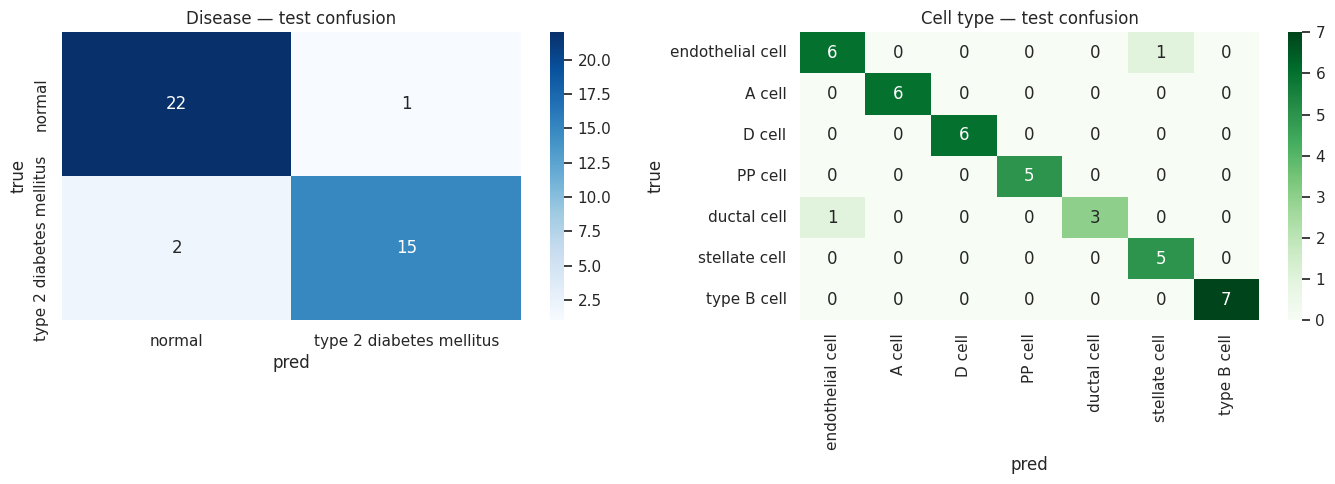

In [23]:
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix
import numpy as np, matplotlib.pyplot as plt, seaborn as sns

gnn.eval()
yd_true, yd_pred, yc_true, yc_pred = [], [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        _, pred_class, pred_class_ct = gnn(batch)
        yd_true += batch.y.cpu().tolist();    yd_pred += pred_class.argmax(-1).cpu().tolist()
        yc_true += batch.y_ct.cpu().tolist(); yc_pred += pred_class_ct.argmax(-1).cpu().tolist()

print("── Disease (normal vs T2D) ──")
print(f"  balanced acc {balanced_accuracy_score(yd_true, yd_pred):.3f} | "
      f"macro-F1 {f1_score(yd_true, yd_pred, average='macro'):.3f}")
print("── Cell type (7 classes) ──")
print(f"  balanced acc {balanced_accuracy_score(yc_true, yc_pred):.3f} | "
      f"macro-F1 {f1_score(yc_true, yc_pred, average='macro'):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(yd_true, yd_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=disease_names, yticklabels=disease_names, ax=ax[0])
ax[0].set_title("Disease — test confusion"); ax[0].set_xlabel("pred"); ax[0].set_ylabel("true")
sns.heatmap(confusion_matrix(yc_true, yc_pred), annot=True, fmt="d", cmap="Greens",
            xticklabels=[c.replace("pancreatic ", "") for c in ct_names],
            yticklabels=[c.replace("pancreatic ", "") for c in ct_names], ax=ax[1])
ax[1].set_title("Cell type — test confusion"); ax[1].set_xlabel("pred"); ax[1].set_ylabel("true")
plt.tight_layout(); plt.show()

### Graph-embedding PCA (coloured by disease and by cell type)

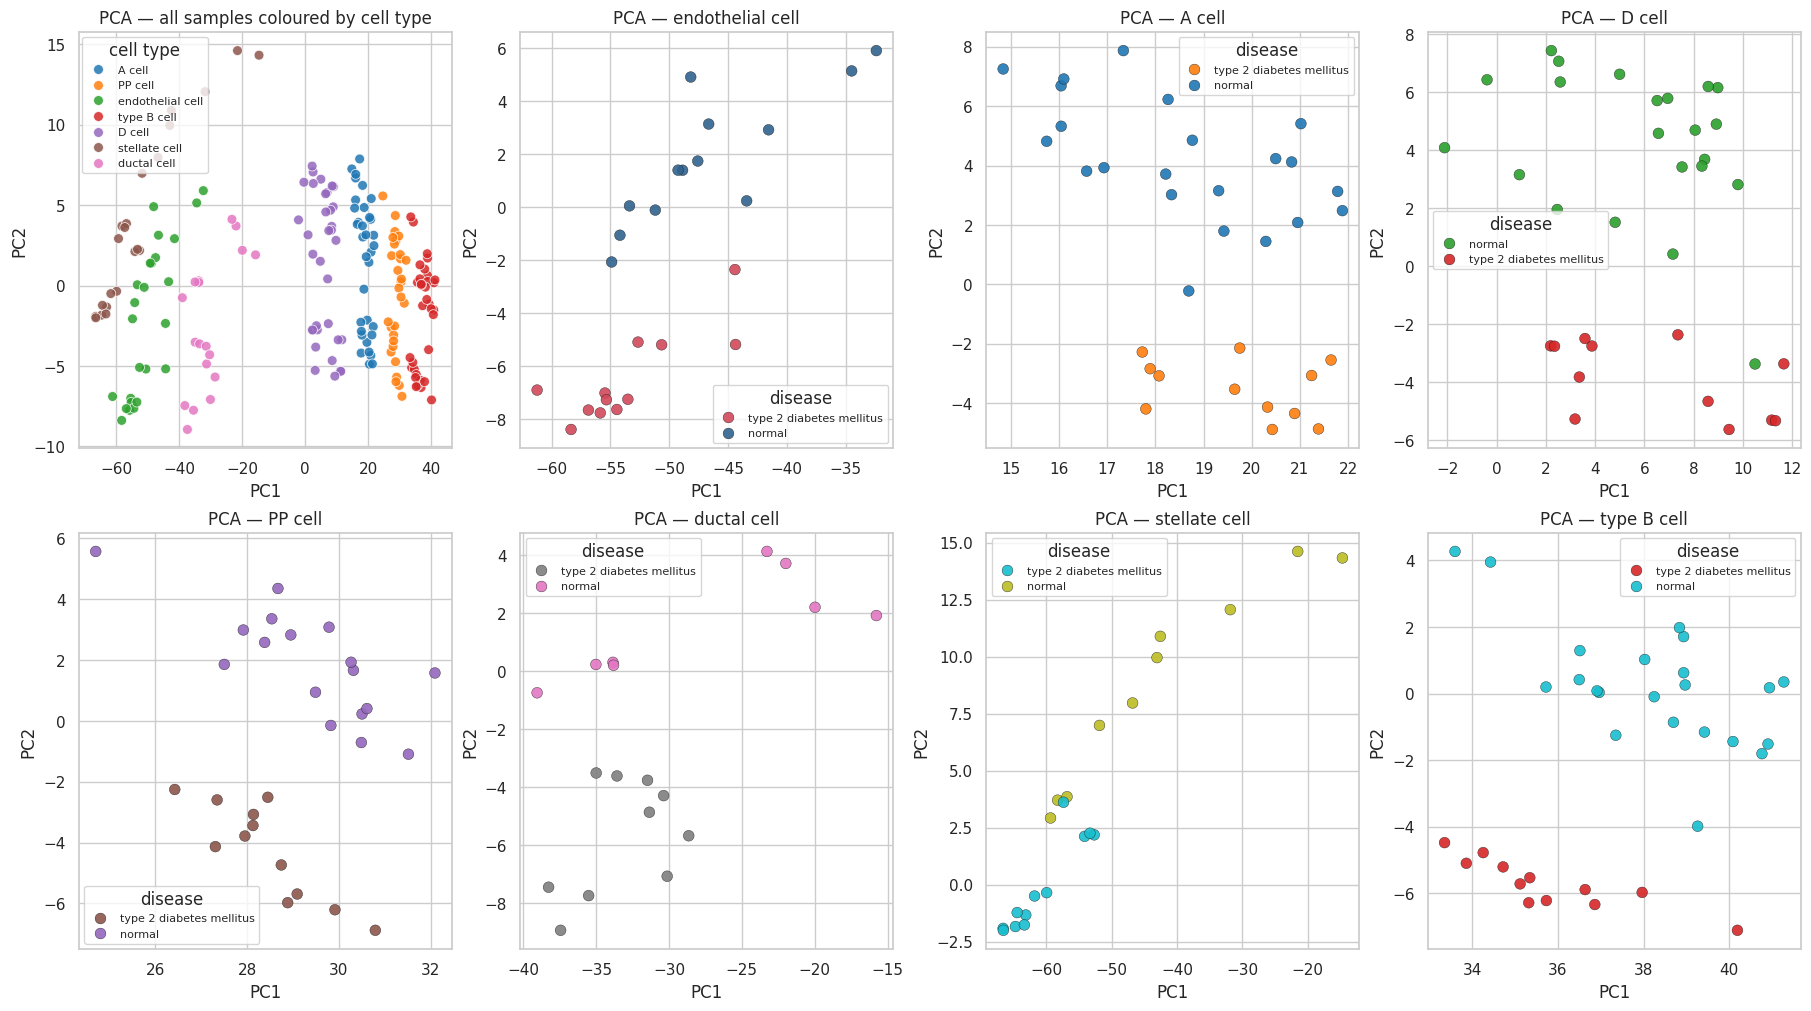

In [24]:
from sklearn.decomposition import PCA

gnn.eval()
Z, zy, zyc = [], [], []
with torch.no_grad():
    for batch in train_loader:
        batch = batch.to(device)
        _, z_graph = gnn.encode(batch)
        Z.append(z_graph.cpu().numpy())
        zy.extend(batch.y.cpu().tolist())
        zyc.extend(batch.y_ct.cpu().tolist())

    for batch in test_loader:
        batch = batch.to(device)
        _, z_graph = gnn.encode(batch)
        Z.append(z_graph.cpu().numpy())
        zy.extend(batch.y.cpu().tolist())
        zyc.extend(batch.y_ct.cpu().tolist())

Z = np.concatenate(Z, axis=0)
coords = PCA(n_components=2, random_state=42).fit_transform(Z)

cell_type_short = [ct.replace("pancreatic ", "") for ct in ct_names]
df = pd.DataFrame(coords, columns=["PC1", "PC2"])
df["disease"] = [disease_names[i] for i in zy]
df["cell_type"] = [cell_type_short[i] for i in zyc]

disease_palettes = [
    {"normal": "#30638e", "type 2 diabetes mellitus": "#d1495b"},
    {"normal": "#1f77b4", "type 2 diabetes mellitus": "#ff7f0e"},
    {"normal": "#2ca02c", "type 2 diabetes mellitus": "#d62728"},
    {"normal": "#9467bd", "type 2 diabetes mellitus": "#8c564b"},
    {"normal": "#e377c2", "type 2 diabetes mellitus": "#7f7f7f"},
    {"normal": "#bcbd22", "type 2 diabetes mellitus": "#17becf"},
    {"normal": "#17becf", "type 2 diabetes mellitus": "#d62728"},
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10), constrained_layout=True)
axes = axes.ravel()

sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="cell_type",
    palette=sns.color_palette("tab10", len(cell_type_short)),
    s=50,
    alpha=0.85,
    ax=axes[0],
)
axes[0].set_title("PCA — all samples coloured by cell type")
axes[0].legend(title="cell type", fontsize=8, bbox_to_anchor=(0.36, 1), loc="upper right")

for i, ct in enumerate(cell_type_short):
    ax = axes[i + 1]
    subset = df[df["cell_type"] == ct]
    sns.scatterplot(
        data=subset,
        x="PC1",
        y="PC2",
        hue="disease",
        palette=disease_palettes[i],
        s=60,
        alpha=0.9,
        edgecolor="k",
        linewidth=0.3,
        ax=ax,
    )
    ax.set_title(f"PCA — {ct}")
    ax.legend(title="disease", fontsize=8)

plt.show()

## Applying `GEA` to trained model's embeddings

### Extracting embeddings

In [25]:
from gea.gea import export_embeddings

emb_paths = export_embeddings(
    gnn,
    embed_loader,
    device,
    out_dir="data/t2d",
    prefix="t2d_emb",
    gene_names=gene_list_ppi,   # node order the graphs were built with
    label_names=disease_names,
    ct_names=ct_names,
    # dtype=np.float16,         # halves the ~790 MB node+edge footprint
)

Extracting graph-level embeddings: 100%|██████████| 7/7 [00:00<00:00, 28.54it/s]


graph-level:       196 rows × 128 dims → data/t2d/t2d_emb_graph.npz


Extracting node-level embeddings: 100%|██████████| 7/7 [00:00<00:00,  7.76it/s]


 node-level:   201,880 rows × 128 dims → data/t2d/t2d_emb_node.npz


Extracting edge-level embeddings: 100%|██████████| 7/7 [00:03<00:00,  2.15it/s]


 edge-level:   859,724 rows × 128 dims → data/t2d/t2d_emb_edge.npz


### EmbeddingDataset class

In [26]:
from torch.utils.data import DataLoader as EmbeddingLoader
from gea.dataloader import EmbeddingDataset
from gea.gea import set_seed

graph_emb = EmbeddingDataset(emb_paths["graph"])
node_emb = EmbeddingDataset(emb_paths["node"])
edge_emb = EmbeddingDataset(emb_paths["edge"])

In [27]:
for emb in graph_emb:
    print(emb)
    break

{'embedding': tensor([ -3.0671,  -1.8353,  -2.2207,   4.3200,  -2.1426,   8.3056,  -4.0256,
         14.9758, -11.0092,   4.3207,  13.1220, -10.9281,  -3.2683,  -0.8888,
          1.6614,   1.1236,   6.0101, -10.9506,  -1.3365,   4.4949,   3.8964,
          2.4157,  -3.9523,  -1.6874,  -3.8358, -13.0286,  -6.2519,  -1.6650,
         -2.1879,  -9.7138,   0.1179,   0.2973,  -9.0297, -14.1797,  -2.1138,
         -5.9637,  -6.4582,   1.4351,  12.1837,   3.4637,  10.5246,  -1.1592,
         -1.2367,  -2.9377,  -2.9731,  11.9044,   4.9434,  -1.7990,  -1.6982,
         -7.7190,   9.5329, -10.8377,   1.5195,   2.0107,  -0.0527,  -6.8951,
        -10.5397,  -5.0155,  -1.4536,   8.2419,  -3.5848,  -3.1384,   8.9614,
          4.7024,  -1.7012,  13.8785,  -0.6551,  -3.4913,  -1.3330,   4.0063,
          8.4575,   0.6423,   0.2469,  -3.6659,   1.2009,  12.7670,   2.9621,
         -1.8738,   2.2148,   9.6199,  -0.6229,  -8.9735,  -0.2400,   0.1809,
         -0.8135,  -5.9939,  -6.3161,   1.6741,  -

### Training graph-level SAE

In [28]:
from torch.utils.data import DataLoader as EmbeddingLoader

from gea.dataloader import EmbeddingDataset
from gea.gea import set_seed, ShallowSAE, train_sae

set_seed(42)  # reproducible weight init

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# One embedding per graph, carrying its sample name, phenotype and cell type
graph_emb = EmbeddingDataset(emb_paths["graph"])
print(f"{len(graph_emb):,} graph embeddings of dim {graph_emb[0]['embedding'].shape[0]}")
print("annotations (biological groups, one-hot):",
      {k: v.tolist() for k, v in graph_emb[0]["annotation"].items()})

sae_graph = ShallowSAE(in_dim=d_z, latent_dim=d_z * 8, sparsity_weight=1e-3).to(device)

train_sae(
    sae_model=sae_graph,
    train_loader=EmbeddingLoader(graph_emb, batch_size=32, shuffle=True),
    device=device,
    epochs=500,
    w_l2 = 0,
)

196 graph embeddings of dim 128
annotations (biological groups, one-hot): {'disease': [1.0, 0.0], 'cell_type': [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]}


Training SAE model:   0%|          | 0/3500 [00:00<?, ?it/s]

Training SAE model: 100%|██████████| 3500/3500 [00:12<00:00, 291.57it/s, epoch=499/501, total_loss=0.0592]


### Training node-level SAE

In [29]:
from torch.utils.data import DataLoader as EmbeddingLoader

from gea.dataloader import EmbeddingDataset
from gea.gea import set_seed, ShallowSAE, train_sae

set_seed(42)  # reproducible SAE weight init

# One embedding per (graph, gene). Each row knows which gene of which graph it is.
node_emb = EmbeddingDataset(emb_paths["node"])
print(f"{len(node_emb):,} node embeddings — e.g. {node_emb[0]['entity']}")

sae_node = ShallowSAE(in_dim=d_z, latent_dim=d_z * 8, sparsity_weight=1e-3).to(device)

# Batch size and epoch count differ from the graph-level SAE because an epoch here
# is ~1,000× more rows: 30 epochs of 4,096-row batches is ~1.5k updates (~2 min on
# CPU), already more than the graph-level SAE sees in 100 epochs.
train_sae(
    sae_model=sae_node,
    train_loader=EmbeddingLoader(node_emb, batch_size=4096, shuffle=True, num_workers=4),
    device=device,
    epochs=100,
    w_l2 = 0,
)

201,880 node embeddings — e.g. mouse_pancreatic_islet_atlas_Hrovatin__NOD_elimination__SRR7610296|pancreatic_stellate_cell|normal::ENSMUSG00000074896


Training SAE model: 100%|██████████| 5000/5000 [07:02<00:00, 11.83it/s, epoch=99/101, total_loss=0.0930]


### Training edge-level SAE

In [30]:
from torch.utils.data import DataLoader as EmbeddingLoader

from gea.dataloader import EmbeddingDataset
from gea.gea import set_seed, ShallowSAE, train_sae

set_seed(42)  # reproducible SAE weight init

# One embedding per (graph, gene pair). The signed co-expression weight is kept as
# an annotation, so a feature can later be traced to positively vs negatively
# correlated pairs.
edge_emb = EmbeddingDataset(emb_paths["edge"])
print(f"{len(edge_emb):,} edge embeddings — e.g. {edge_emb[0]['entity']} "
      f"(weight {edge_emb[0]['annotation']['weight']:+.3f})")

sae_edge = ShallowSAE(in_dim=d_z, latent_dim=d_z * 8, sparsity_weight=1e-3).to(device)

# ~860k rows per epoch → 20 epochs is ~4.2k updates (~6 min on CPU).
train_sae(
    sae_model=sae_edge,
    train_loader=EmbeddingLoader(edge_emb, batch_size=4096, shuffle=True, num_workers=4),
    device=device,
    epochs=100,
    w_l2 = 0,
)

859,724 edge embeddings — e.g. mouse_pancreatic_islet_atlas_Hrovatin__NOD_elimination__SRR7610296|pancreatic_stellate_cell|normal::ENSMUSG00000029084--ENSMUSG00000039542 (weight +0.371)


Training SAE model: 100%|██████████| 21000/21000 [27:27<00:00, 12.75it/s, epoch=99/101, total_loss=0.0744] 


### Saving model checkpoints

In [31]:
import torch
from pathlib import Path

ckpt_path = Path("data/t2d/t2d_checkpoints.pt")
ckpt_path.parent.mkdir(parents=True, exist_ok=True)


def weights(model):
    """State dict on CPU, so a checkpoint trained on GPU still loads on a CPU box."""
    return {k: v.detach().cpu() for k, v in model.state_dict().items()}


def sae_config(sae):
    return dict(in_dim=sae.in_dim, latent_dim=sae.latent_dim,
                sparsity_weight=sae.sparsity_weight)


# Constructor kwargs travel with the weights so every model can be rebuilt without
# re-reading this notebook, and the gene / label order is kept because the weights
# are meaningless without it: node features are ordered by gene_list_ppi, and the
# y, y_ct and one-hot annotations are positions in disease_names / ct_names.
torch.save(
    {
        "gnn": {
            "state_dict": weights(gnn),
            "config": dict(in_channels=in_dim, n_classes=n_classes,
                           n_classes_ct=n_classes_ct, latent_dim=d_z,
                           input_proj_dim=None),
        },
        "sae_graph": {"state_dict": weights(sae_graph), "config": sae_config(sae_graph)},
        "sae_node": {"state_dict": weights(sae_node), "config": sae_config(sae_node)},
        "sae_edge": {"state_dict": weights(sae_edge), "config": sae_config(sae_edge)},
        "gene_order": gene_list_ppi,
        "disease_names": disease_names,
        "ct_names": ct_names,
        "embedding_paths": emb_paths,
        "seed": 42,
    },
    ckpt_path,
)
print(f"saved {ckpt_path} ({ckpt_path.stat().st_size / 1e6:.1f} MB)")

saved data/t2d/t2d_checkpoints.pt (4.7 MB)


### Realoding model checkpoints

In [32]:
from torch.utils.data import DataLoader as EmbeddingLoader

from gea.dataloader import EmbeddingDataset
from gea.gea import set_seed, ShallowSAE, train_sae

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt = torch.load("data/t2d/t2d_checkpoints.pt", map_location=device, weights_only=False)

gnn = GNNModel(**ckpt["gnn"]["config"]).to(device)
gnn.load_state_dict(ckpt["gnn"]["state_dict"])

sae_graph = ShallowSAE(**ckpt["sae_graph"]["config"]).to(device)
sae_graph.load_state_dict(ckpt["sae_graph"]["state_dict"])

sae_node = ShallowSAE(**ckpt["sae_node"]["config"]).to(device)
sae_node.load_state_dict(ckpt["sae_node"]["state_dict"])

sae_edge = ShallowSAE(**ckpt["sae_edge"]["config"]).to(device)
sae_edge.load_state_dict(ckpt["sae_edge"]["state_dict"])

<All keys matched successfully>

### Clustered heatmap of graph-level SAE features

Alive: 28/1024 features (996 dead or constant, dropped)


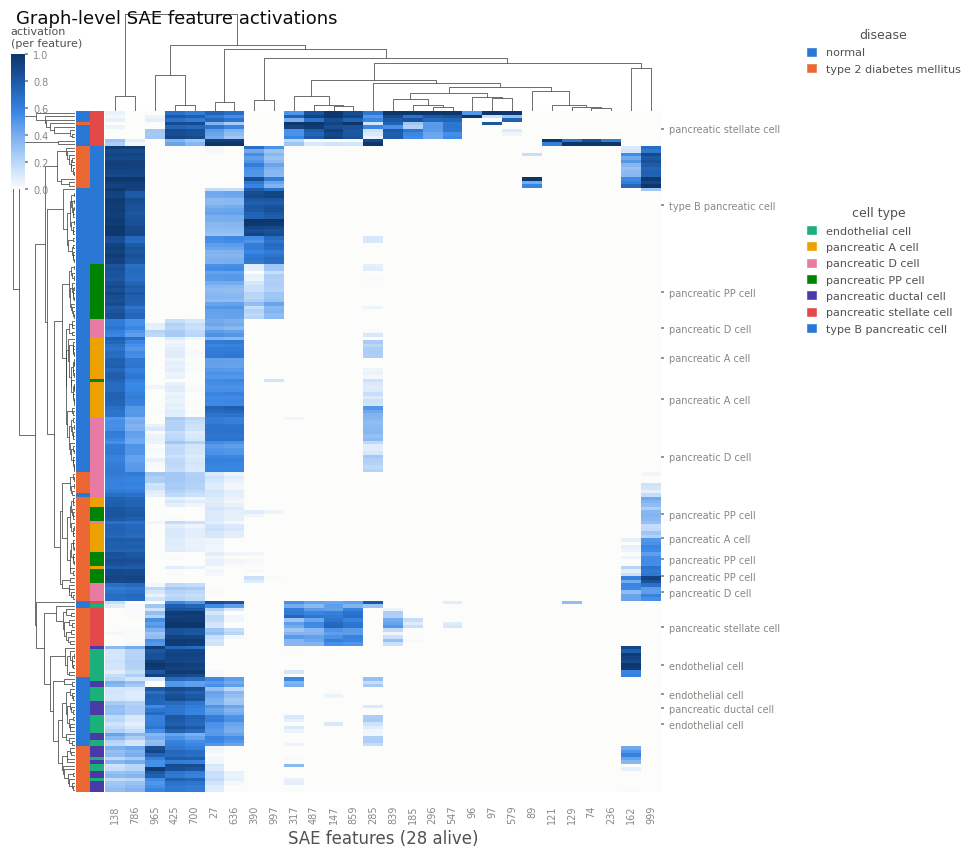

In [33]:
from gea.analysis import extract_sae_activations, plot_sae_feature_clustermap

# Activations of the trained graph-level SAE, one row per pseudobulk profile, with
# the identity from the embedding export attached (graph_id, disease, cell_type).
graph_acts_df = extract_sae_activations(sae_graph, emb_paths["graph"], device)

# Rows and features are both hierarchically clustered. Features that never fire —
# or fire in <5% of profiles — are dropped first: a dead feature cannot cluster and
# only flattens the colour scale. Each feature column is min-max scaled so that a
# couple of loud features do not wash out the rest (pass scale="none" for raw
# activation magnitudes).
g, alive_features = plot_sae_feature_clustermap(
    graph_acts_df,
    annotate=("disease", "cell_type"),   # one strip each, listed most-important first
    min_activation_frac=0.01,
)

# Contiguous blocks of clustered rows are labelled in text on the right, because
# seven cell-type hues cannot all be told apart by colour alone.
g.figure.savefig("data/t2d/t2d_sae_graph_clustermap.png", dpi=200,
                 bbox_inches="tight", facecolor="#fcfcfb")